In [161]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score,precision_recall_curve
from sklearn.model_selection import RandomizedSearchCV

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

C:\Users\patel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [162]:
path = kagglehub.dataset_download("isaikumar/creditcardfraud")
df = pd.read_csv(path + "/creditcard.csv")

100%|██████████| 65.9M/65.9M [00:22<00:00, 3.10MB/s]

Extracting files...


In [2]:
df = pd.read_csv('creditcard.csv')

In [163]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [4]:
df['Time'] = (df['Time'] // 3600) % 24

<Axes: xlabel='Class', ylabel='Density'>

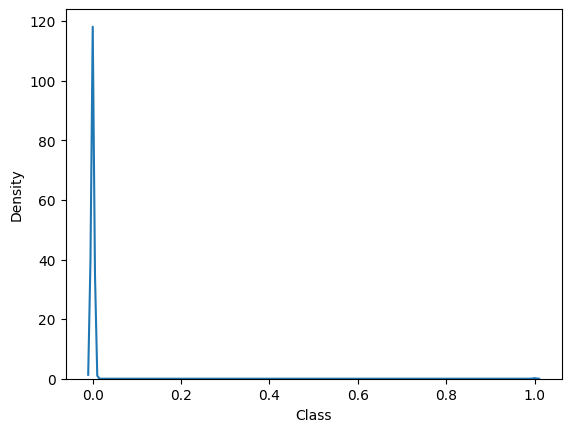

In [5]:
sns.kdeplot(df.iloc[:,-1])

<Axes: xlabel='Amount', ylabel='Density'>

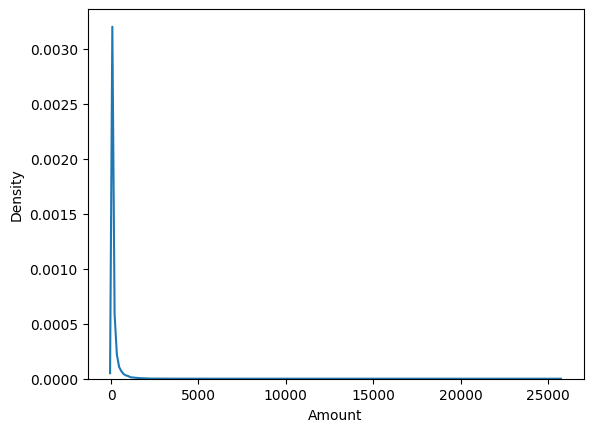

In [6]:
sns.kdeplot(df['Amount'])

<Axes: xlabel='Time', ylabel='Density'>

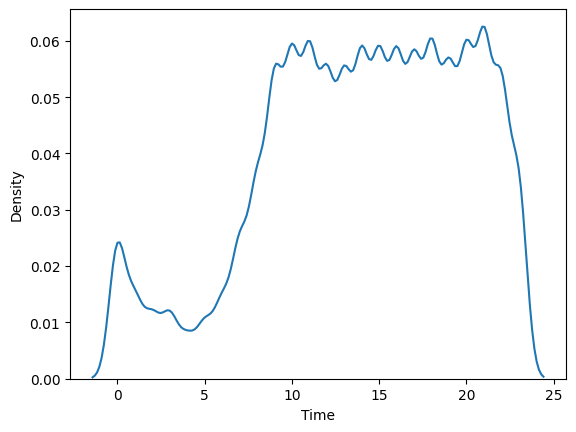

In [7]:
sns.kdeplot(df['Time'])

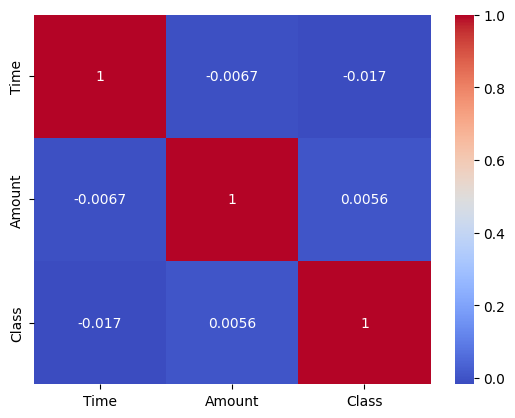

In [8]:
corr = df[['Time','Amount','Class']].corr()

sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.show()

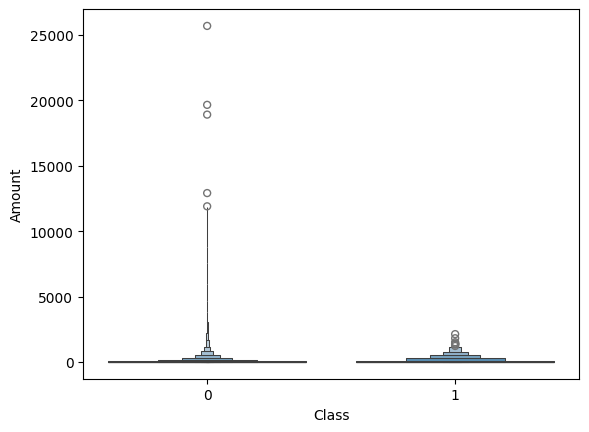

In [9]:
sns.boxenplot(x='Class', y='Amount', data=df)
plt.show()

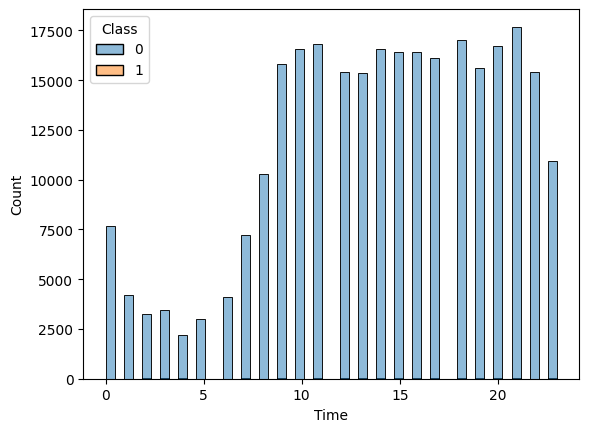

In [10]:
sns.histplot(data=df, x='Time', hue='Class', bins=50)
plt.show()

In [11]:
X = df.drop('Class',axis=1)
y = df['Class']

In [12]:
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size= 0.2) 

In [13]:
pipeline = Pipeline([
    ('model', XGBClassifier())
])

In [14]:
pipeline.fit(X_train,y_train)

,steps,"[('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None


In [15]:
y_pred = pipeline.predict(X_test)

In [16]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56865
           1       0.85      0.84      0.84        97

    accuracy                           1.00     56962
   macro avg       0.93      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [17]:
cm = confusion_matrix(y_test,y_pred)

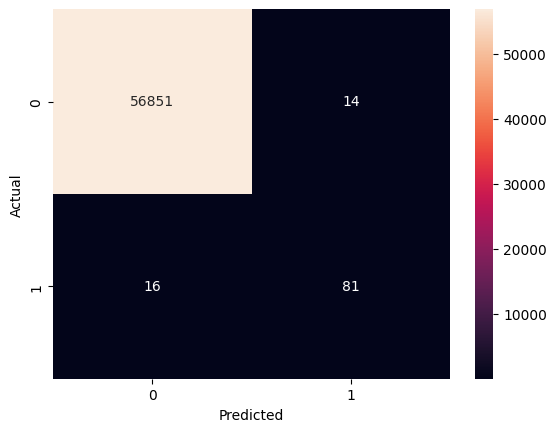

In [18]:
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [19]:
y_prob = pipeline.predict_proba(X_test)[:,1]

In [20]:
roc_auc = roc_auc_score(y_test,y_prob)
print("ROC-AUC",roc_auc)

ROC-AUC 0.9637029644274149


In [21]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

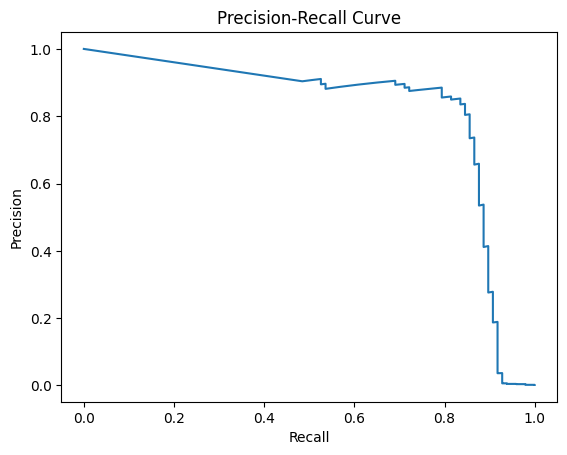

In [22]:
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [23]:
y_prob = pipeline.predict_proba(X_test)[:,1]

In [24]:
for t in[0.5,0.3,0.2,0.1]:
    y_pred_t = (y_prob >=t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_t))


Threshold: 0.5
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56865
           1       0.85      0.84      0.84        97

    accuracy                           1.00     56962
   macro avg       0.93      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962


Threshold: 0.3
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56865
           1       0.84      0.85      0.84        97

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962


Threshold: 0.2
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56865
           1       0.82      0.85      0.83        97

    accuracy                           1.00     56962
   macro avg       0.91      0.92      0.92     56962
weighted avg       1.00   

In [ ]:
param_dist = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.05, 0.03],
    'model__subsample': [0.7, 0.8, 1.0],
    'model__gamma': [0,2,4]
}

In [26]:
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring='recall',
    cv=3,
    verbose=1,
    n_jobs=-1
)

In [27]:
random_search.fit(X_train,y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'model__gamma': [0, 2, ...], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 5, ...], 'model__n_estimators': [100, 200, ...], ...}"
,n_iter,20
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [28]:
best_model = random_search.best_estimator_

In [29]:
y_prob = best_model.predict_proba(X_test)[:,1]

In [30]:
for t in(0.5,0.3,0.2,0.1):
    y_pred_t = (y_prob >= t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_t))


Threshold: 0.5
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56865
           1       0.95      0.85      0.90        97

    accuracy                           1.00     56962
   macro avg       0.98      0.92      0.95     56962
weighted avg       1.00      1.00      1.00     56962


Threshold: 0.3
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56865
           1       0.94      0.88      0.91        97

    accuracy                           1.00     56962
   macro avg       0.97      0.94      0.95     56962
weighted avg       1.00      1.00      1.00     56962


Threshold: 0.2
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56865
           1       0.91      0.90      0.90        97

    accuracy                           1.00     56962
   macro avg       0.95      0.95      0.95     56962
weighted avg       1.00   

In [31]:
y_pred = (y_prob >= 0.2).astype(int)

In [32]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56865
           1       0.91      0.90      0.90        97

    accuracy                           1.00     56962
   macro avg       0.95      0.95      0.95     56962
weighted avg       1.00      1.00      1.00     56962



In [120]:
pipeline = Pipeline([
    ('smote', SMOTE(sampling_strategy=0.1)),
    ('model',XGBClassifier())
])

In [121]:
param_dist = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5],
    'model__learning_rate': [0.05, 0.1],
    'model__scale_pos_weight': [5, 10, 20],
    'smote__k_neighbors': [3, 5]
}

| Value | Meaning                     |
| ----- | --------------------------- |
| 5     | fraud is 5× more important  |
| 10    | fraud is 10× more important |
| 20    | fraud is 20× more important |


If:

smote__k_neighbors = 5

Then:

For each fraud sample
SMOTE looks at 5 nearest fraud neighbors
Creates synthetic points between them

In [122]:
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1',
    cv=3,
    verbose=1,
    n_jobs=-1
)

In [123]:
random_search.fit(X_train,y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'model__learning_rate': [0.05, 0.1], 'model__max_depth': [3, 5], 'model__n_estimators': [100, 200], 'model__scale_pos_weight': [5, 10, ...], ...}"
,n_iter,20
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [138]:
best_model = random_search.best_estimator_

y_prob = best_model.predict_proba(X_test)[:,1]
y_pred = (y_prob >= 0.912).astype(int)

In [139]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56865
           1       0.91      0.91      0.91        97

    accuracy                           1.00     56962
   macro avg       0.95      0.95      0.95     56962
weighted avg       1.00      1.00      1.00     56962



In [143]:
X_temp, X_test, y_temp, y_test = train_test_split(df.drop('Class',axis=1),df['Class'], test_size=0.15)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2)

In [144]:
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'model__learning_rate': [0.05, 0.1], 'model__max_depth': [3, 5], 'model__n_estimators': [100, 200], 'model__scale_pos_weight': [5, 10, ...], ...}"
,n_iter,20
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [156]:
best_model = random_search.best_estimator_

y_prob = best_model.predict_proba(X_test)[:,1]
y_pred = (y_prob >= 0.65).astype('int')

In [157]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42645
           1       0.78      0.78      0.78        77

    accuracy                           1.00     42722
   macro avg       0.89      0.89      0.89     42722
weighted avg       1.00      1.00      1.00     42722



In [158]:
from sklearn.metrics import average_precision_score

average_precision_score(y_test, y_prob)

0.787706103319816

In [159]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

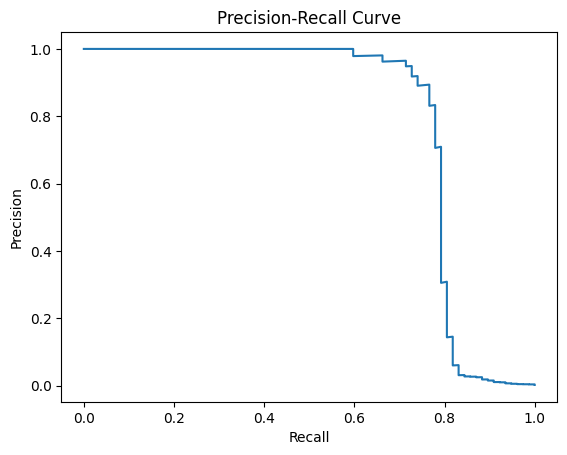

In [160]:
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()